# Model Comparison and Validation

In [2]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Optional XGBoost
try:
    from xgboost import XGBRegressor
    xgb_available = True
except:
    xgb_available = False

In [3]:
models = {

    "Linear Regression":

    LinearRegression(),


    "Decision Tree":

    DecisionTreeRegressor(
        random_state=42
    ),


    "Random Forest":

    RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),


    "Gradient Boosting":

    GradientBoostingRegressor(
        random_state=42
    )

}


if xgb_available:

    models["XGBoost"] = XGBRegressor(

        n_estimators=200,

        learning_rate=0.05,

        random_state=42

    )

In [6]:
import pandas as pd

df = pd.read_csv(
    "../data/renewable_energy_transition_ENHANCED_FINAL.csv"
)

df.head()

,Country Code,Country Name,year,renew_share,co2_pc,gdp_pc,population,ln_co2_pc,ln_gdp_pc,ln_population,...,co2_change_rate,energy_transition_category,renewables_share_elec,solar_share_elec,wind_share_elec,hydro_share_elec,fossil_share_elec,coal_share_elec,gas_share_elec,low_carbon_share_elec
0,AFG,Afghanistan,2000,45.0,0.050138,308.318270,20130327,-2.992970,5.731133,16.817738,...,0.000000,Medium,64.583,0.0,0.0,64.583,35.417,0.000,0.0,64.583
1,AFG,Afghanistan,2001,45.6,0.046351,277.118051,20284307,-3.071510,5.624444,16.825358,...,-7.553467,Medium,72.464,0.0,0.0,72.464,27.536,5.797,0.0,72.464
2,AFG,Afghanistan,2002,37.8,0.043914,338.139974,21378117,-3.125521,5.823460,16.877878,...,-5.257779,Medium,78.873,0.0,0.0,78.873,21.127,5.634,0.0,78.873
3,AFG,Afghanistan,2003,36.7,0.044745,346.071627,22733049,-3.106766,5.846646,16.939330,...,1.893160,Medium,69.231,0.0,0.0,69.231,30.769,9.890,0.0,69.231
4,AFG,Afghanistan,2004,44.2,0.038301,338.637274,23560654,-3.262276,5.824930,16.975089,...,-14.402106,Medium,70.886,0.0,0.0,70.886,29.114,7.595,0.0,70.886


In [10]:
features = [

    "renew_share",
    "gdp_pc",
    "population",
    "electricity_access",
    "energy_use_per_capita",

    "fossil_fuel_energy_share",
    "urban_population",

    "renewable_growth_rate",

    "fossil_dependency_index",
    "energy_transition_score",

    "renewables_share_elec",
    "solar_share_elec",
    "wind_share_elec",
    "hydro_share_elec",

    "fossil_share_elec",
    "coal_share_elec",
    "gas_share_elec",

    "low_carbon_share_elec"

]


target = "co2_pc"



In [11]:
# Time-based split

train_data = df[
    df["year"] <= 2019
]


test_data = df[
    df["year"] >= 2020
]


X_train = train_data[features]

X_test = test_data[features]


y_train = train_data[target]

y_test = test_data[target]

In [12]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2416, 18)
X_test: (282, 18)
y_train: (2416,)
y_test: (282,)


In [13]:
results = []


for name, model in models.items():

    print("Training:", name)


    model.fit(
        X_train,
        y_train
    )


    prediction = model.predict(
        X_test
    )


    mae = mean_absolute_error(
        y_test,
        prediction
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )


    r2 = r2_score(
        y_test,
        prediction
    )


    results.append({

        "Model": name,

        "MAE": mae,

        "RMSE": rmse,

        "R2 Score": r2

    })

Training: Linear Regression
Training: Decision Tree
Training: Random Forest
Training: Gradient Boosting
Training: XGBoost


In [14]:
comparison = pd.DataFrame(results)


comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
)


comparison

,Model,MAE,RMSE,R2 Score
2,Random Forest,0.184305,0.348937,0.975542
1,Decision Tree,0.213814,0.409194,0.966366
4,XGBoost,0.228548,0.418209,0.964867
3,Gradient Boosting,0.275782,0.428468,0.963123
0,Linear Regression,0.639878,0.839062,0.858580


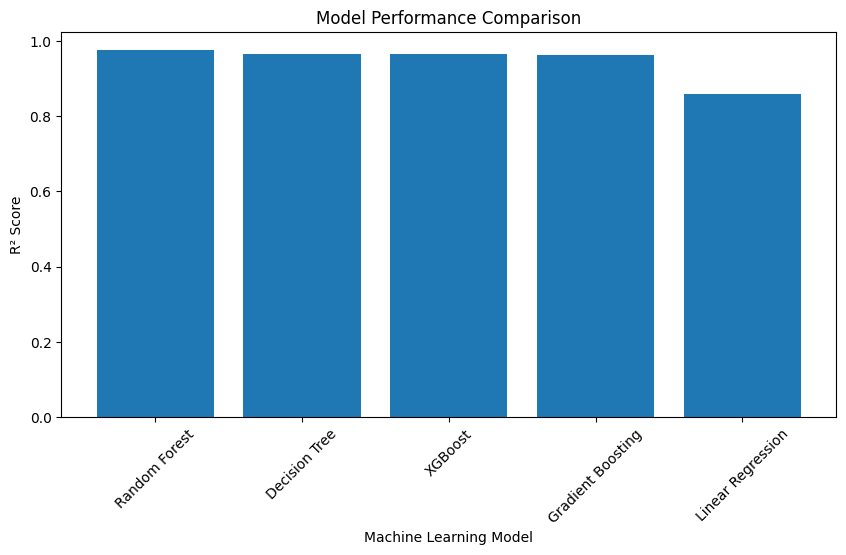

In [15]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

plt.bar(
    comparison["Model"],
    comparison["R2 Score"]
)

plt.ylabel(
    "R² Score"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.title(
    "Model Performance Comparison"
)

plt.xticks(
    rotation=45
)

plt.show()